In [4]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='1min';Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [5]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [6]:
#DOMAIN SUBSETTING
############################################################
ocean_percent=2/8

left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
end_xh=len(data['xh'])-1-50
end_xf=len(data['xf'])-1-50

print(f'x in {0}:{where_coast_xh-1} FOR SEA')
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# t_end=78 
# if res=='250m':t_end=410
# print(f't in {0}:{t_end} (6.5 hours)')
if t_res=="5min":
    t_start=36 # 9:00 am (3 hours in)
if t_res=="1min":
    t_start=36*5 # 9:00 am (3 hours in)
print(f't in {t_start}:end (8 hours)')


#SUBSETTING CODE
data=data.isel(time=slice(t_start,None),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1))
parcel=parcel.isel(time=slice(t_start,None))

x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 180:end (8 hours)


In [7]:
#JOB ARRAY SETUP
job_array=False;index_adjust=0
job_array=True

if job_array==True:

    num_jobs=120 #60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(data['time']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    print(f'start_job = {start_job}, end_job = {end_job}')

start_job = 0, end_job = 5


In [8]:
if job_array==True:
    #Indexing Array with JobArray
    data=data.isel(time=slice(start_job,end_job))
    parcel=parcel.isel(time=slice(start_job,end_job))
    #(for 150_000_000 parcels use 500-1000 jobs)

In [9]:
def call_variables(): #***
    variable='winterp'; w_data=data[variable].data
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data


    #THETA_E AND HMC ARE DOMAIN AND JOB SUBSETTED HERE
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}_{t_res}'+'.h5', 'r') as f:
        if job_array==True:
            theta_e_data = f['theta_e'][t_start:,:,:,slice(where_coast_xh,end_xh+1)][start_job:end_job]
        elif job_array==False:
            theta_e_data = f['theta_e'][t_start:,:,:,slice(where_coast_xh,end_xh+1)][:]
    
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{t_res}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        if job_array==True:
            HMC_data = f['conv'][t_start:,:,:,slice(where_coast_xh,end_xh+1)][start_job:end_job]
        elif job_array==False:
            HMC_data = f['conv'][t_start:,:,:,slice(where_coast_xh,end_xh+1)][:]
    return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data

print('calling variables')
[w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data]=call_variables()
print('done')

calling variables
done


In [ ]:
##########################################################################################
#Functions
# Full Profile function makes profile together for all timesteps. AveragedProfiles funciton takes the final mean of the combined profile.

In [10]:
# Thresholds
w_thresh1 = 0.1
w_thresh2 = 0.5
qcqi_thresh = 1e-6

def final_profile(vars_list, type):
    zhs = data['zh'].values
    profiles = {}  # Store profiles for all variables

    # Initialize profiles for each variable
    for var in vars_list:
        profiles[var] = np.zeros((len(zhs), 3))  # column 1: var, column 2: counter, column 3: list of zhs
        profiles[var][:, 2] = zhs

    # Threshold mask
    if type == "general":
        where_updraft = (w_data >= w_thresh1) & (qc_plus_qi < qcqi_thresh)
    elif type == "cloudy":
        where_updraft = (w_data >= w_thresh2) & (qc_plus_qi >= qcqi_thresh)
    t_ind, z_ind, y_ind, x_ind = np.where(where_updraft)

    # Variable selection dictionary
    var_data = {
        'w': w_data, 'qv': qv_data, 'qc': qc_plus_qi, 'qi': qi_data,
        'th': th_data, 'th_e': theta_e_data, 'buoyancy': buoyancy_data, 'HMC': HMC_data
    }

    # Iterate over each variable in vars_list and bin the data
    for var in vars_list:
        masked_data = var_data[var][where_updraft]
        np.add.at(profiles[var][:, 0], z_ind, masked_data)
        np.add.at(profiles[var][:, 1], z_ind, 1)

    return profiles

In [ ]:
##########################################################################################
#Running

In [12]:
dir2=dir+'Project_Algorithms/Domain_Profiles/'

for type in ['general','cloudy']:
    print(f"working on {type} type\n")
    
    vars_list = ['w', 'qv', 'qc', 'qi', 'th', 'th_e', 'buoyancy', 'HMC']
    profiles = final_profile(vars_list, type)
    
    #Saving eulerian_profiles
    import h5py
    
    if type == "general":
        output_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}'
    elif type == "cloudy":
        output_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}'

    if job_array==True:
        output_file+=f'_{job_id}.h5'
    elif job_array==False:
        output_file+=f'.h5'
    
    with h5py.File(output_file, 'w') as f:
        for var in profiles:
            profile_var = profiles[var]
            f.create_dataset(f'profile_{var}', data=profile_var, compression="gzip")

working on general type

working on cloudy type



In [14]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE WHEN JOB ARRAY IS RUNNING
# recombine=True

In [16]:
if recombine==True:
    dir2=dir+'Project_Algorithms/Domain_Profiles/'
    
    types=['general','cloudy']
    for type in types:
        #MAKING OUTPUT FILE PATH
        if type == "general":
            output_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            output_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
        
        #MAKING PROFILES DICTIONARY
        zhs = data['zh'].values
        profiles = {}  # Store profiles for all variables
        vars_list = ['w', 'qv', 'qc', 'qi', 'th', 'th_e', 'buoyancy', 'HMC']
        for var in vars_list:
            profiles[var] = np.zeros((len(zhs), 3))  # column 1: var, column 2: counter, column 3: list of zhs
            profiles[var][:, 2] = zhs 
        
        num_jobs=120
        for job_id in np.arange(1,num_jobs+1):
            if np.mod(job_id,10)==0: print(f"job_id = {job_id}")
            if job_id==2:break
            #CALLING IN DATA
            if type == "general":
                input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5' 
            elif type == "cloudy":
                input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
    
            #COMPILING PROFILES
            with h5py.File(input_file, 'r') as f:
                for var in vars_list:  
                    profiles[var][:,0:1+1]+=f[f'profile_{var}'][:,0:1+1]
        
        #SAVING INTO FINAL FORM
        with h5py.File(output_file, 'w') as f:
            for var in profiles:
                profile_var = profiles[var]
                f.create_dataset(f'profile_{var}', data=profile_var, compression="gzip")

In [17]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB ARRAY IS RUNNING
plotting=True

In [18]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

currently on type general
currently on type cloudy


IndexError: index 0 is out of bounds for axis 0 with size 0

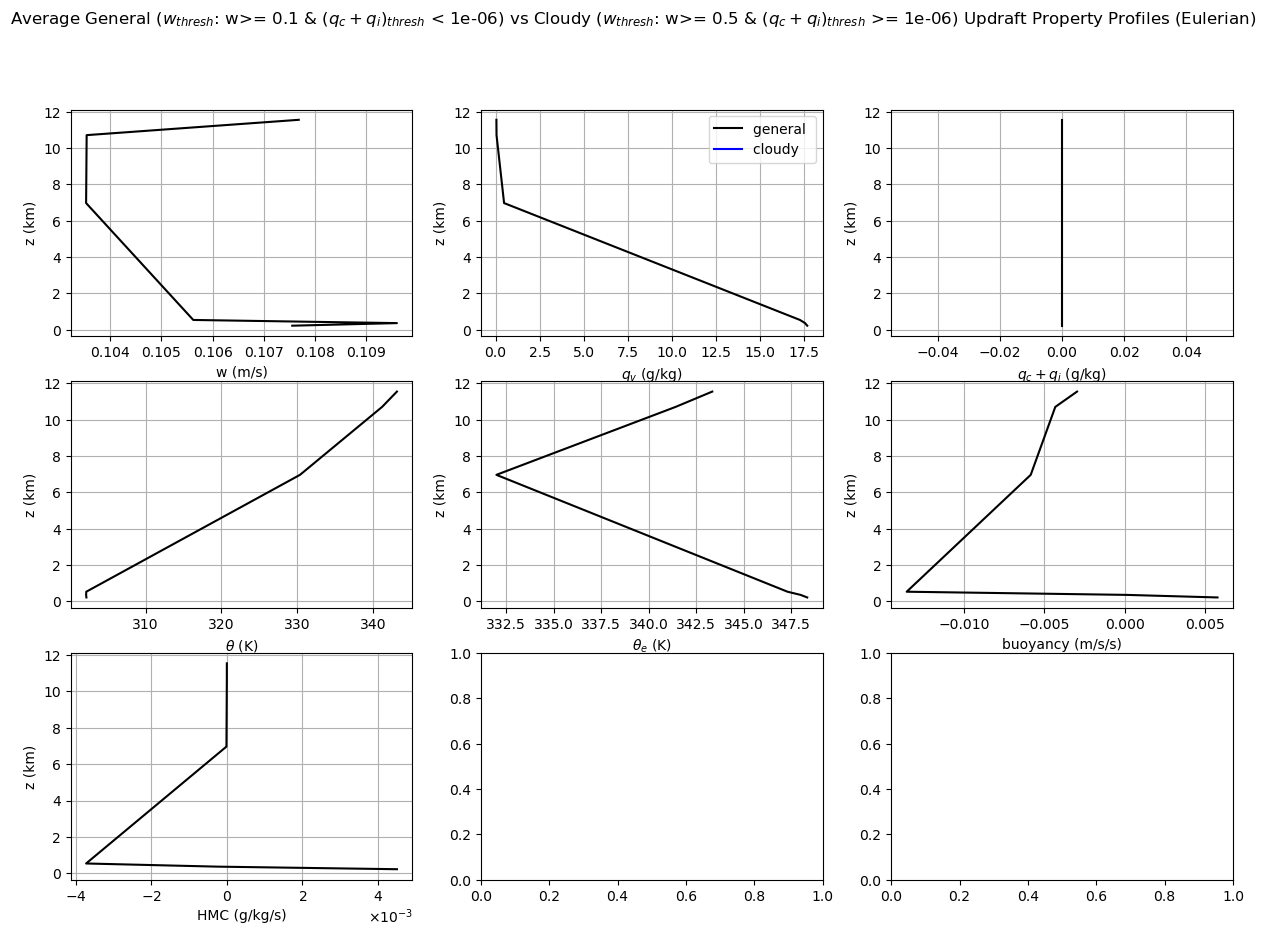

In [20]:
if plotting==True:
        
    #Produced averaged profiles for plotting
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    ####################################################################
    res='1km'
    # res='250m'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    # if type=='general':
    #     fig.suptitle(f"average eulerian updraft property profiles") 
    # if type=='cloudy':
    #     fig.suptitle(f"average eulerian cloudy updraft property profiles")
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Eulerian)")
    #CHANGE TITLE IF CTRL CASE IF USING
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
    # plt.tight_layout()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
    
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
    
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_th_e = np.array(f['profile_th_e'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
            profile_HMC = np.array(f['profile_HMC'])
        
        #Plotting function
        def plotting(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        vars=['w','qv','qc','th','th_e','buoyancy', 'HMC']
        # vars=['w'] #TESTING
        for var in vars:
            globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])
        
        vars=['w','qv','qc','th','th_e','buoyancy','HMC'] 
        # vars=['w'] #TESTING
        axises=[ax1,ax2,ax3,ax4,ax5,ax6,ax7] #ax5
        xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)', 'HMC (g/kg/s)'] 
        for var,axis,xlabel in zip(vars,axises,xlabels):
            if type=='general':
                color='k'
            elif type=='cloudy':
                color='blue'
    
            #converts qv and qc from kg/kg=>g/kg
            if var in ['qv','qc','HMC']:
                globals()[f"out_{var}"][:,0]*=1000
    
            
            plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
    
            if axis==ax2:
                axis.legend(); #add legend
    
            if axis==ax7:
                apply_scientific_notation([axis])
    
    
    #MEAN CLOUD BASE
    qcqi_profile=averaged_profiles(profile_qc)
    where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
    cloudbase=qcqi_profile[where_cloudbase,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed')
    
    
    
    plt.tight_layout()
    #save plot
    plt.savefig(dir+f'Project_Algorithms/plots/eulerian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 
    # plt.savefig(dir+f'Project_Algorithms/plots/eulerian_generalvscloudy_updraft_profile_CTRL_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)


In [17]:
# #TESTING W (T,Z) PLOT #CLOUDY

# # #READING BACK IN
# # dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# # file_path = dir2 + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{Np_str}' + '.h5'
# # with h5py.File(file_path, 'r') as f:
# #      profile_array_VMF_c = f['conv'][:]

# # masked_profile2 = profile_array_VMF_c.copy()
# # VMF_tz = np.nanmean(masked_profile2, axis=(0,2, 3))
# # print('done')

# # New Subplots for Contour Plots
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# #First plot
# axes[0].plot(VMF_tz*1000,data['zh'])
# axes[0].set_title('HMC(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)


# # mask1 = (data['winterp'] >= 0.5) & ((data['qc'] + data['qi']) >= 1e-6)
# # # masked_profile1 = np.ma.masked_where(~mask1, profile_array_VMF_c)
# # masked_profile1 = np.where(~mask1, np.nan, profile_array_VMF_c)
# # VMF_tz_A = np.nanmean(masked_profile1, axis=(0, 2, 3))
# # print('done')

# #Second plot
# axes[1].plot(VMF_tz_A*1000,data['zh'])
# axes[1].set_title('HMC(z) Horizontal Average for Eulerian Data (w ≥ 0.5) & (qc+qi ≥ 1e-6)',fontsize=8)


# apply_scientific_notation([axes[0],axes[1]])
# plt.suptitle('Horizontal Average of 3D HMC For Entire Domain vs Within Cloudy Updrafts')
# plt.tight_layout()

In [18]:
# #TESTING W (T,Z) PLOT #GENERAL

# #READING BACK IN
# dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# file_path = dir2 + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{Np_str}' + '.h5'
# with h5py.File(file_path, 'r') as f:
#      profile_array_VMF_c = f['conv'][:]


# masked_profile2 = profile_array_VMF_c.copy()
# VMF_tz = np.nanmean(masked_profile2, axis=(0,2, 3))
# print('done')

# # New Subplots for Contour Plots
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# #First plot
# axes[0].plot(VMF_tz*1000,data['zh'])
# axes[0].set_title('HMC(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)



# mask1 = (data['winterp'] >= 0.1) & ((data['qc'] + data['qi']) < 1e-6)
# # masked_profile1 = np.ma.masked_where(~mask1, profile_array_VMF_c)
# masked_profile1 = np.where(~mask1, np.nan, profile_array_VMF_c)
# VMF_tz_A = np.nanmean(masked_profile1, axis=(0, 2, 3))
# print('done')

# #Second plot
# axes[1].plot(VMF_tz_A*1000,data['zh'])
# axes[1].set_title('HMC(z) Horizontal Average for Eulerian Data (w ≥ 0.1) & (qc+qi < 1e-6)',fontsize=8)


# apply_scientific_notation([axes[0],axes[1]])
# plt.suptitle('Horizontal Average of 3D HMC For Entire Domain vs Within General Updrafts')
# plt.tight_layout()

In [104]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

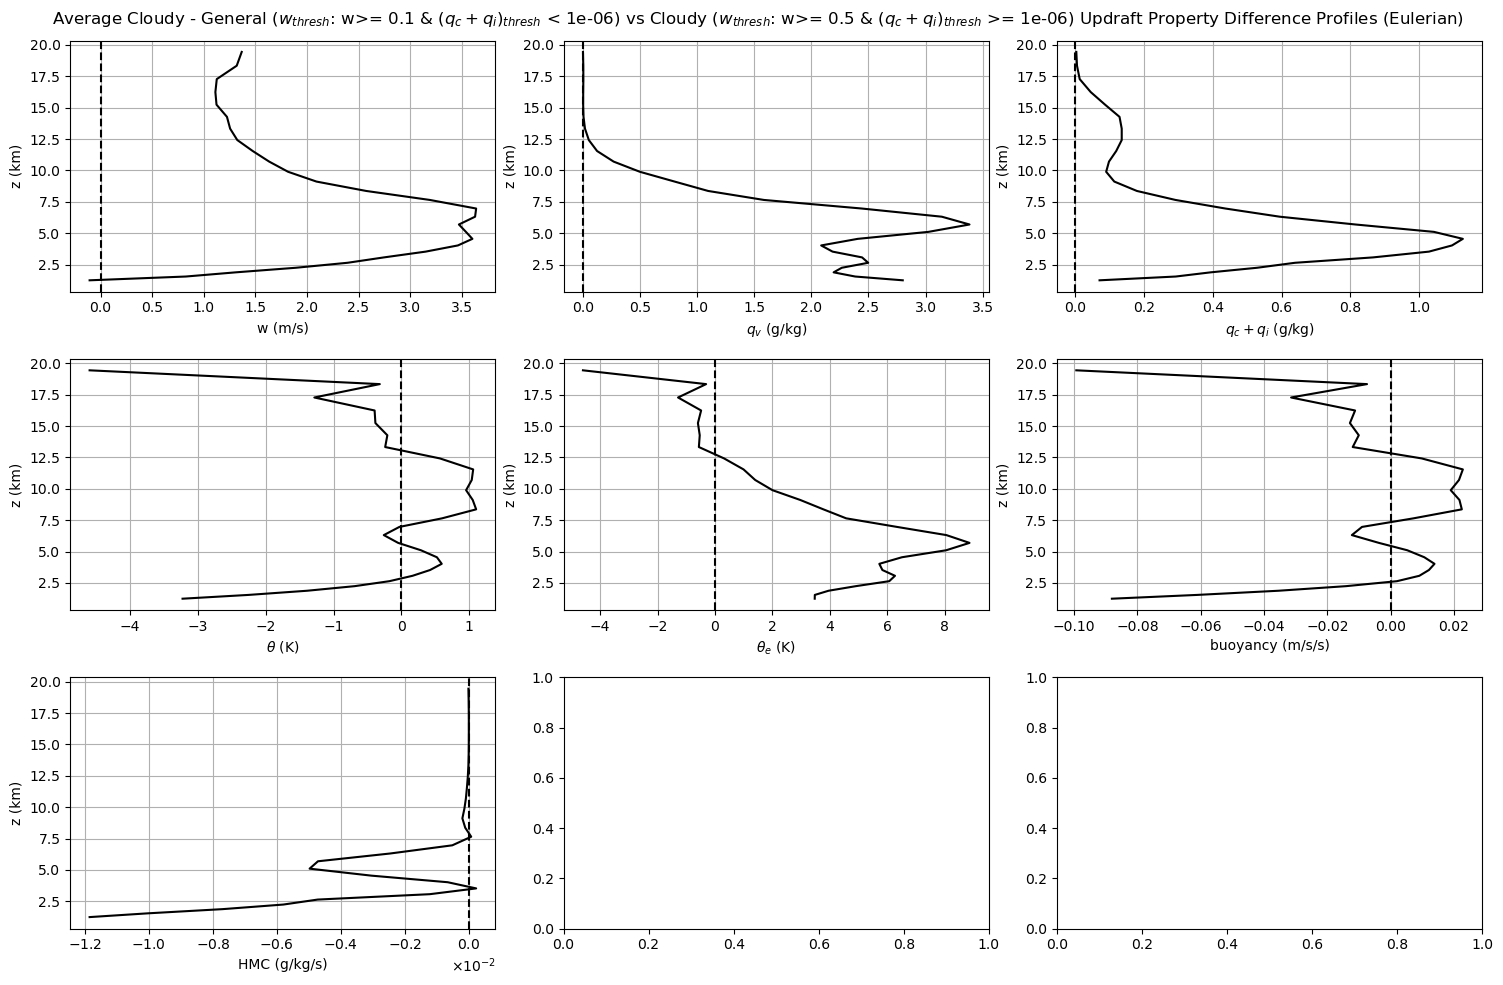

In [106]:
if plotting==True:
    #Plotting Differences
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    label=1
    
        
    def get_data(type):
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{Np_str}_5min.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{Np_str}_5min.h5'
            
        with h5py.File(input_file, 'r') as f:
            globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
            globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
            globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
            globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
            globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
            globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
            globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])
            globals()[f'{type}_profile_HMC'] = np.array(f['profile_HMC'])
    
        
    def diff_plotting():
        #setting up figure
        fig, axs = plt.subplots(3, 3, figsize=(15, 10))
        fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Eulerian)")
        ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
    
        #the plotting
        vars=['w','qv','qc','th','th_e','buoyancy','HMC']
        xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
        for xlabel,var in zip(xlabels,vars):
            
            if var=='w':axis=ax1
            elif var=='qv':axis=ax2
            elif var=='qc':axis=ax3
            elif var=='th':axis=ax4
            elif var=='th_e':axis=ax5
            elif var=='buoyancy':axis=ax6
            elif var=='HMC':axis=ax7
    
            #get profile
            types=['cloudy','general']
            get_data(types[0])
            out_var_one=globals()[f"{types[0]}_profile_{var}"]
            get_data(types[1])
            out_var_two=globals()[f"{types[1]}_profile_{var}"]
    
            #finding where cloudy updraft count goes below 10
            cutofflow=np.where(out_var_one[:,1]>10)[0][0]
            cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
           
            #averaging
            out_var_diff=average_difference(out_var_one,out_var_two)
    
            #converts qv and qc from kg/kg=>g/kg
            if var in ['qv','qc','qi','HMC']:
                out_var_diff[:,0]*=1000
            
            axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
            axis.axvline(0,color='k',linestyle='dashed')
            # axis.set_ylim(bottom=0,top=20)
            ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
            #labeling
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
            axis.grid(True)
            # axis.legend(fontsize='small') #only adds legend at final variable
    
            if axis==ax7:
                apply_scientific_notation([axis])
    
            # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        plt.tight_layout()
    
    # #MEAN CLOUD BASE
    # for axis in axises:
    #     axis.axhline(cloudbase,color='purple',linestyle='dashed')
        plt.savefig(dir+f'Project_Algorithms/plots/eulerian_updraft_profiles_diff_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) #save plot
    diff_plotting() 

In [ ]:
#OTHER TESTING
######################################################

In [12]:
# #Loading in Equivalent Potential Temperature
# with h5py.File(dir+'theta_e_approx.h5', 'r') as f:
#     # Load the dataset by its name
#     theta_e_approx = f['theta_e_approx'][:]

# with h5py.File(dir+'theta_e.h5', 'r') as f:
#     # Load the dataset by its name
#     theta_e_data = f['theta_e'][:]

In [13]:
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     emptylike=True
    
# def final_profile(var,type):
#     global w_thresh
#     #thresholds
#     w_thresh=1
#     qcqi_thresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqi_thresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft

#     #gets data associated with threshold mask
#     if var=='w':
#         masked_data=w_data[where_updraft]
#     if var=='qv':
#         masked_data=qv_data[where_updraft]
#     if var=='qc':
#         masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
#     if var=='qi':
#         masked_data=qi_data[where_updraft]
#     if var=='th':
#         masked_data=th_data[where_updraft]
#     if var=='buoyancy':
#         masked_data=buoyancy_data[where_updraft]
#     if var=='theta_e':
#         masked_data=theta_e_data[where_updraft]
#     if var=='theta_e_test':
#         masked_data=theta_e_approx[where_updraft]
        
#     #converts qv and qc from kg/kg=>g/kg
#     if var in ['qv','qc','qi']:
#         masked_data*=1000

#     #bin masked values by z level
#     for (kh,value) in zip(z_ind,masked_data):
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
#     return profile_array

loading neccessary variables


In [14]:
# x1=final_profile('theta_e','general')
# x2=final_profile('theta_e','cloudy')

# x3=final_profile('theta_e_test','general')
# x4=final_profile('theta_e_test','cloudy')

In [8]:
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# x1_avg=averaged_profiles(x1)
# x2_avg=averaged_profiles(x2)

# plt.plot(x1_avg[:,0],x1_avg[:,1],label='general updraft',color='k')
# plt.plot(x2_avg[:,0],x2_avg[:,1],label='cloudy updraft',color='blue')
# plt.legend();

# x3_avg=averaged_profiles(x3)
# x4_avg=averaged_profiles(x4)


# plt.plot(x3_avg[:,0],x3_avg[:,1],label='general updraft - approx',color='k',linestyle='dashed')
# plt.plot(x4_avg[:,0],x4_avg[:,1],label='cloudy updraft - approx',color='b',linestyle='dashed')
# plt.legend();
# plt.title(r'$\theta_e$'+' in General vs Cloudy Updrafts')

# plt.xlim((330,380))

In [9]:
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# x1_avg=averaged_profiles(x1)
# x2_avg=averaged_profiles(x2)

# plt.plot(x1_avg[:,0],x1_avg[:,1],label='general updraft',color='k')
# plt.plot(x2_avg[:,0],x2_avg[:,1],label='cloudy updraft',color='blue')
# plt.legend();

# # x3_avg=averaged_profiles(x3)
# # x4_avg=averaged_profiles(x4)


# # plt.plot(x3_avg[:,0],x3_avg[:,1],label='general updraft - approx',color='k',linestyle='dashed')
# # plt.plot(x4_avg[:,0],x4_avg[:,1],label='cloudy updraft - approx',color='b',linestyle='dashed')
# # plt.legend();
# # plt.title(r'$\theta_e$'+' in General vs Cloudy Updrafts')

# plt.xlim((330,380))